# Northwind Analysis
<img src = "../assets/ERD.PNG">

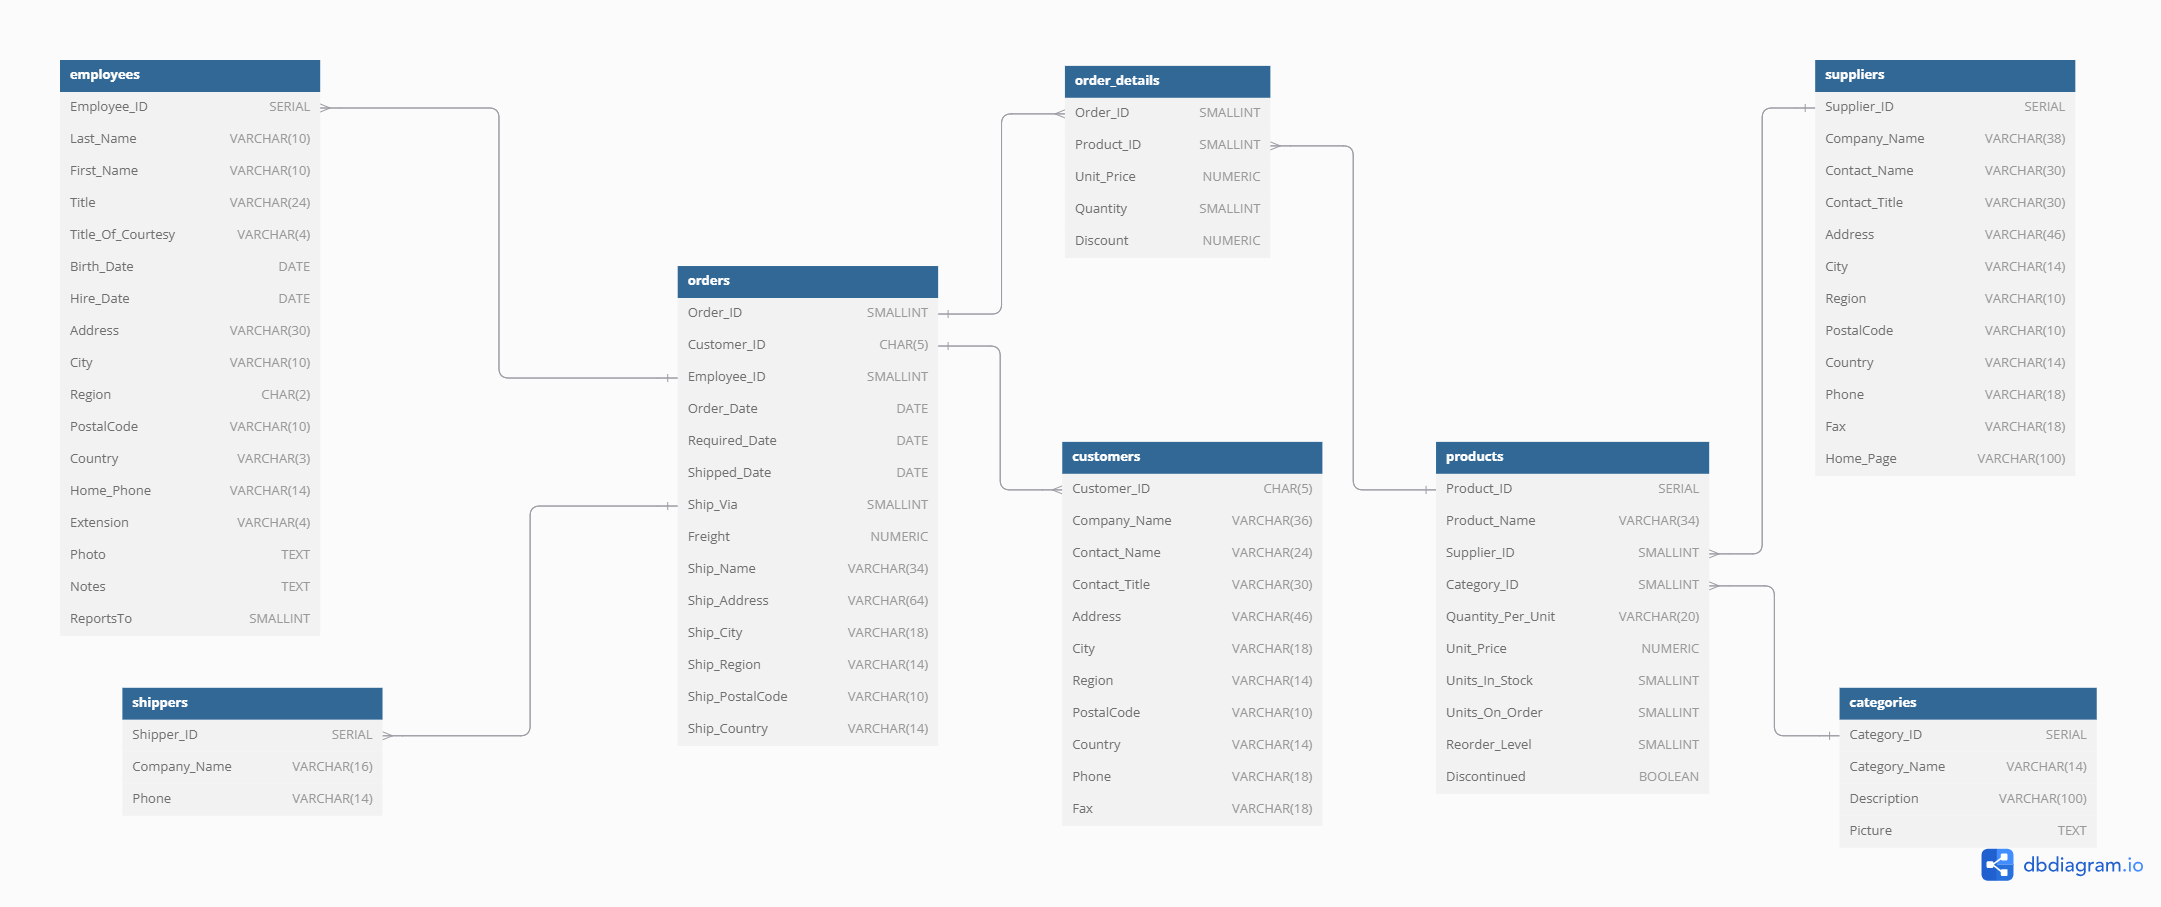

In [1]:
from IPython.display import Image

# Display the image
Image(filename='../assets/ERD.PNG')

## Importing the Required Libraries

In [1]:
import pandas as pd
import pyodbc

import warnings
warnings.filterwarnings("ignore")

## Connecting to the PostgreSQL database

In [2]:
import psycopg2

In [3]:
hostname = 'localhost'
database = 'Northwind'
username = 'postgres'
pwd = 'Seriously'
port_id = 5432

In [4]:
try:
    conn = psycopg2.connect(host= hostname,
                            dbname = database,
                            user = username,
                            password = pwd,
                            port = port_id
                            )
except Exception as error:
    print(error) 

In [5]:
cur = conn.cursor()

## Analysis -  Answering Business Requests

### Q1. We’d like to see just the FirstName, LastName, and HireDate of all the employees with the Title of Sales Representative and are in USA?

In [6]:
a1_script = """
SELECT
    first_name,
    last_name,
    hire_date
FROM employees;"""
a1_sql = pd.read_sql(a1_script,conn)
a1_sql

,first_name,last_name,hire_date
0,Nancy,Davolio,1992-05-01
1,Andrew,Fuller,1992-08-14
2,Janet,Leverling,1992-04-01
3,Margaret,Peacock,1993-05-03
4,Steven,Buchanan,1993-10-17
5,Michael,Suyama,1993-10-17
6,Robert,King,1994-01-02
7,Laura,Callahan,1994-03-05
8,Anne,Dodsworth,1994-11-15


### Q2.  Show all the orders placed by the Employee with the ID of 5. Order the records based on their history. Save the records in a csv file with the title a2?

In [7]:
a2_script = """
SELECT
    order_id,
    order_date
FROM orders
WHERE
    employee_id = 5
ORDER BY order_date
;"""

a2_sql = pd.read_sql(a2_script,conn)
a2_sql.to_csv('../data/a2.csv')
a2_sql

,order_id,order_date
0,10248,1994-08-04
1,10254,1994-08-11
2,10269,1994-08-31
3,10297,1994-10-05
4,10320,1994-11-03
5,10333,1994-11-18
6,10358,1994-12-21
7,10359,1994-12-22
8,10372,1995-01-04
9,10378,1995-01-10


### Q3. In the Suppliers table, show the SupplierID, ContactName, and ContactTitle for those Suppliers whose ContactTitle is not Marketing Manager?


In [8]:
a3_script = """
SELECT
    supplier_id,
    contact_name,
    contact_title
FROM suppliers
WHERE contact_title <> 'Marketing Manager'
;"""

a3_sql = pd.read_sql(a3_script,conn)
a3_sql

,supplier_id,contact_name,contact_title
0,1,Charlotte Cooper,Purchasing Manager
1,2,Shelley Burke,Order Administrator
2,3,Regina Murphy,Sales Representative
3,5,Antonio del Valle Saavedra,Export Administrator
4,6,Mayumi Ohno,Marketing Representative
5,8,Peter Wilson,Sales Representative
6,9,Lars Peterson,Sales Agent
7,11,Petra Winkler,Sales Manager
8,12,Martin Bein,International Marketing Mgr.
9,13,Sven Petersen,Coordinator Foreign Markets


### Q4. We’d like to see the ProductID and ProductName for those products where the ProductName includes the string “Schokolade”?


In [9]:
a4_script = """
SELECT
    product_id,
    product_name
FROM products
WHERE
 product_name like '%Schokolade%'
;"""

a4_sql = pd.read_sql(a4_script,conn)
a4_sql

,product_id,product_name
0,27,Schoggi Schokolade


### Q5. We want to show all the orders from any Latin American country which includes the countries of Brazil, Mexico, Argentina, Venezuela?

In [10]:
a5_script = """
SELECT
    order_id,
    customer_id,
    ship_country
FROM orders
WHERE
 ship_country in ('Brazil','Mexico',' Argentina','Venezuela')
;"""

a5_sql = pd.read_sql(a5_script,conn)
a5_sql.to_csv('../data/a5.csv')
a5_sql

,order_id,customer_id,ship_country
0,10395,HILAA,Venezuela
1,10405,LINOD,Venezuela
2,10406,QUEEN,Brazil
3,10414,FAMIA,Brazil
4,10250,HANAR,Brazil
...,...,...,...
152,11065,LILAS,Venezuela
153,11068,QUEEN,Brazil
154,11069,TORTU,Mexico
155,11071,LILAS,Venezuela


### Q6. How many customers do we have in the Customers in the company?


In [11]:
a6_script = """
SELECT
    COUNT(*) AS total_employees
FROM customers
;"""

a6_sql = pd.read_sql(a6_script,conn)
a6_sql

,total_employees
0,91


### Q7. Show the details of the first order ever made in the Orders table?

In [12]:
a7_script = """
SELECT
    *
FROM orders
WHERE order_date = (SELECT  min(order_date)
                   FROM Orders)
;"""

a7_sql = pd.read_sql(a7_script,conn)
a7_sql

,order_id,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postalcode,ship_country
0,10248,VINET,5,1994-08-04,1994-09-01,1994-08-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,None,51100,France


### Q8. Show a list of all the different values in the Customers table for ContactTitles. Also include a count for each ContactTitle and order the records based on the count descendingly?

In [13]:
a8_script = """
SELECT
    contact_title,
    COUNT(*) AS TotalCount
FROM customers 
GROUP BY contact_title
ORDER BY COUNT(*)  DESC;
"""

a8_sql = pd.read_sql(a8_script,conn)
a8_sql

,contact_title,totalcount
0,Owner,17
1,Sales Representative,17
2,Marketing Manager,12
3,Sales Manager,11
4,Accounting Manager,10
5,Sales Associate,7
6,Marketing Assistant,6
7,Sales Agent,5
8,Assistant Sales Agent,2
9,Order Administrator,2


### Q9. We’d like to show, for each product, the associated Supplier. Show the ProductID, ProductName, and the CompanyName of the Supplier. Sort by ProductID?


In [14]:
a9_script = """
SELECT
    p.product_id,
    p.product_name,
    s.company_name AS supplier
FROM products  p
JOIN suppliers s
    ON p.supplier_id = s.supplier_id
ORDER BY p.product_id;
"""

a9_sql = pd.read_sql(a9_script,conn)
a9_sql

,product_id,product_name,supplier
0,1,Chai,Exotic Liquids
1,2,Chang,Exotic Liquids
2,3,Aniseed Syrup,Exotic Liquids
3,4,Chef Anton's Cajun Seasoning,New Orleans Cajun Delights
4,5,Chef Anton's Gumbo Mix,New Orleans Cajun Delights
...,...,...,...
72,73,Röd Kaviar,Svensk Sjöföda AB
73,74,Longlife Tofu,Tokyo Traders
74,75,Rhönbräu Klosterbier,Plutzer Lebensmittelgroßmärkte AG
75,76,Lakkalikööri,Karkki Oy


### Q10. We’d like to show a list of the Orders that were made, including the Shipper that was used. Show the OrderID, OrderDate (date only), and CompanyName of the Shipper, and sort by OrderID. Show only those rows with an OrderID of less than 10300?

In [15]:
a10_script = """
SELECT
    o.order_id,
    o.order_date,
    s.company_name AS shipper
FROM orders  o
JOIN shippers s
    ON o.ship_via = s.shipper_id
WHERE o.order_id < 10300;
"""

a10_sql = pd.read_sql(a10_script,conn)
a10_sql.to_csv('../data/a10')
a10_sql

,order_id,order_date,shipper
0,10248,1994-08-04,Federal Shipping
1,10249,1994-08-05,Speedy Express
2,10250,1994-08-08,United Package
3,10251,1994-08-08,Speedy Express
4,10252,1994-08-09,United Package
5,10253,1994-08-10,United Package
6,10254,1994-08-11,United Package
7,10255,1994-08-12,Federal Shipping
8,10256,1994-08-15,United Package
9,10257,1994-08-16,Federal Shipping


### Q11. For this problem, we’d like to see the total number of products in each category. Sort the results by the total number of products, in descending order?


In [16]:
a11_script = """
SELECT
    ct.category_name,
    COUNT(*) AS total_products
FROM products AS p
JOIN categories AS ct
    ON p.category_id = ct.category_id
GROUP BY 1
ORDER BY 2 DESC;
"""
a11_sql = pd.read_sql(a11_script,conn)

a11_sql

,category_name,total_products
0,Confections,13
1,Seafood,12
2,Condiments,12
3,Beverages,12
4,Dairy Products,10
5,Grains/Cereals,7
6,Meat/Poultry,6
7,Produce,5


### Q12. What products do we have in our inventory that should be reordered? For now, just use the fields UnitsInStock and ReorderLevel, where UnitsInStock is less than the ReorderLevel, ignoring the fields UnitsOnOrder and Discontinued. Order the results by ProductID?


In [17]:
a12_script = """
SELECT
    product_id,
    product_name,
    units_in_stock,
    reorder_level
FROM products 
WHERE units_in_stock <= reorder_level
ORDER BY 1;
"""
a12_sql = pd.read_sql(a12_script,conn)

a12_sql

,product_id,product_name,units_in_stock,reorder_level
0,2,Chang,17,25
1,3,Aniseed Syrup,13,25
2,5,Chef Anton's Gumbo Mix,0,0
3,11,Queso Cabrales,22,30
4,17,Alice Mutton,0,0
5,21,Sir Rodney's Scones,3,5
6,29,Thüringer Rostbratwurst,0,0
7,30,Nord-Ost Matjeshering,10,15
8,31,Gorgonzola Telino,0,20
9,32,Mascarpone Fabioli,9,25


### Q13. We need to incorporate these fields— UnitsInStock, UnitsOnOrder, ReorderLevel, Discontinued—into our calculation. We’ll define “products that need reordering” with the following: UnitsInStock plus UnitsOnOrder are less than or equal to ReorderLevel. The Discontinued flag is false?

In [18]:
a13_script = """
SELECT
    product_id,
    product_name,
    units_in_stock,
    units_on_order,
    reorder_level,
    discontinued
FROM products
WHERE
    ((units_in_stock + units_on_order) <= reorder_level) AND (discontinued is False)
;
"""
a13_sql = pd.read_sql(a13_script,conn)

a13_sql

,product_id,product_name,units_in_stock,units_on_order,reorder_level,discontinued
0,30,Nord-Ost Matjeshering,10,0,15,False
1,70,Outback Lager,15,10,30,False


### Q14. A salesperson for Northwind is going on a business trip to visit customers, and would like to see a list of all customers, sorted by region, alphabetically. However, he wants the customers with no region (null in the Region field) to be at the end, instead of at the top, where you’d normally find the null values. Within the same region, companies should be sorted by CustomerID?

In [19]:
a14_script = """
SELECT
    customer_id,
    company_name,
    region
FROM customers
ORDER BY
    CASE
        WHEN region is NULL THEN 1 ELSE 0
    END,
    region,
    customer_id
;
"""
a14_sql = pd.read_sql(a14_script,conn)
a14_sql.to_csv('../data/a14.csv')
a14_sql

,customer_id,company_name,region
0,OLDWO,Old World Delicatessen,AK
1,BOTTM,Bottom-Dollar Markets,BC
2,LAUGB,Laughing Bacchus Wine Cellars,BC
3,LETSS,Let's Stop N Shop,CA
4,HUNGO,Hungry Owl All-Night Grocers,Co. Cork
...,...,...,...
86,VINET,Vins et alcools Chevalier,None
87,WANDK,Die Wandernde Kuh,None
88,WARTH,Wartian Herkku,None
89,WILMK,Wilman Kala,None


### Q15. Some of the countries we ship to have very high freight charges. We'd like to investigate some more shipping options for our customers, to be able to offer them lower freight charges. Return the three ship countries with the highest average freight overall, in descending order by average freight?

In [20]:
a15_script = """
SELECT
    ship_country,
    AVG(freight) AS avg_freight
FROM orders
GROUP BY ship_country
ORDER BY avg_freight DESC
LIMIT 3;
"""
a15_sql = pd.read_sql(a15_script,conn)
a15_sql

,ship_country,avg_freight
0,Austria,184.787500
1,Ireland,145.012632
2,USA,112.879426


### Q16. We're continuing on the question above on high freight charges. Now, instead of using all the orders we have, we only want to see the top order from the year 1995?

In [21]:
a16_script = """
SELECT
    ship_country,
    AVG(freight) AS avg_freight
FROM orders
WHERE order_date >= '1995-01-01' AND order_date < '1996-01-01'
GROUP BY ship_country
ORDER BY avg_freight DESC
LIMIT 1
;
"""
a16_sql = pd.read_sql(a16_script,conn)
a16_sql

,ship_country,avg_freight
0,Austria,176.736842


### Q17. We now want to get the three ship countries with the highest average freight charges. But instead of filtering for a particular year, we want to use the last 12 months of order data, using as the end date the last OrderDate in Orders?


In [22]:
a17_script = """
SELECT
    ship_country,
    AVG(freight) AS avg_freight
FROM orders
WHERE order_date >= (SELECT MAX(order_date) FROM orders) - INTERVAL '1 year'
GROUP BY ship_country
ORDER BY avg_freight DESC
LIMIT 3
;
"""
a17_sql = pd.read_sql(a17_script,conn)
a17_sql

,ship_country,avg_freight
0,Ireland,200.21000
1,Austria,186.45960
2,USA,117.97046


### Q18. We're doing inventory, and need to show information like the below, for all orders. Sort by OrderID and Product IDderDate in Orders?

In [23]:
a18_script = """
SELECT
    e.employee_id,
    e.last_name,
    o.order_id,
    p.product_name,
    od.quantity
FROM employees e
JOIN orders o
    ON o.employee_id = e.employee_id
JOIN order_details od
    ON o.order_id = od. order_id
JOIN products p
    ON p.product_id = od.product_id
ORDER BY o.order_id, p.product_id
;
"""
a18_sql = pd.read_sql(a18_script,conn)
a18_sql.to_csv('../data/a18.csv')
a18_sql

,employee_id,last_name,order_id,product_name,quantity
0,5,Buchanan,10248,Queso Cabrales,12
1,5,Buchanan,10248,Singaporean Hokkien Fried Mee,10
2,5,Buchanan,10248,Mozzarella di Giovanni,5
3,6,Suyama,10249,Tofu,9
4,6,Suyama,10249,Manjimup Dried Apples,40
...,...,...,...,...,...
2150,1,Davolio,11077,Wimmers gute Semmelknödel,2
2151,1,Davolio,11077,Louisiana Hot Spiced Okra,1
2152,1,Davolio,11077,Röd Kaviar,2
2153,1,Davolio,11077,Rhönbräu Klosterbier,4


### Q19. There are some customers who have never actually placed an order. Show these customers' contact titles?


In [24]:
a19_script = """
SELECT
    c.contact_title
FROM customers c
LEFT JOIN orders o
    ON c.customer_id = o.customer_id
WHERE o.customer_id is NULL 
;
"""
a19_sql = pd.read_sql(a19_script,conn)
a19_sql

,contact_title
0,Accounting Manager
1,Owner


### Q20. One employee (Margaret Peacock, EmployeeID 4) has placed the most orders. However, there are some customers who've never placed an order with her. Show the information of only those customers who have never placed an order with her and reside in USA or Canada?

In [25]:
a20_script = """
SELECT
    c.*
FROM customers c
LEFT JOIN orders o
    ON c.customer_id = o.customer_id AND o.employee_id = 4
WHERE o.customer_id is NULL AND c.country in ('USA','Canada')
;
"""
a20_sql = pd.read_sql(a20_script,conn)
a20_sql

,customer_id,company_name,contact_name,contact_title,address,city,region,postalcode,country,phone,fax
0,LAUGB,Laughing Bacchus Wine Cellars,Yoshi Tannamuri,Marketing Assistant,1900 Oak St.,Vancouver,BC,V3F 2K1,Canada,(604) 555-3392,(604) 555-7293
1,LAZYK,Lazy K Kountry Store,John Steel,Marketing Manager,12 Orchestra Terrace,Walla Walla,WA,99362,USA,(509) 555-7969,(509) 555-6221
2,THEBI,The Big Cheese,Liz Nixon,Marketing Manager,89 Jefferson Way\r\nSuite 2,Portland,OR,97201,USA,(503) 555-3612,None


### Q21. We want to send all of our high-value customers a special VIP gift. We're defining high-value customers as those who've made at least 1 order with a total value (not including the discount) equal to $10,000 or more. We only want to consider orders made in the year 1996?


In [26]:
a21_script = """
SELECT
    c.customer_id,
    c.company_name,
    o.order_id,
    SUM(od.quantity*od.unit_price) AS total_amount
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_details od
    ON o.order_id = od.order_id
WHERE o.order_date >= '1996-01-01' AND o.order_date < '1997-01-01'
GROUP BY 1,2,3
HAVING SUM(od.quantity*od.unit_price) >= 10000
ORDER BY total_amount DESC
;
"""
a21_sql = pd.read_sql(a21_script,conn)
a21_sql

,customer_id,company_name,order_id,total_amount
0,QUICK,QUICK-Stop,10865,17250.00
1,SAVEA,Save-a-lot Markets,11030,16321.90
2,HANAR,Hanari Carnes,10981,15810.00
3,KOENE,Königlich Essen,10817,11490.70
4,RATTC,Rattlesnake Canyon Grocery,10889,11380.00
5,HUNGO,Hungry Owl All-Night Grocers,10897,10835.24


### Q22. The manager has changed his mind. Instead of requiring that customers have at least one individual orders totaling \\$10,000 or more, he wants to define high-value customers as those who have orders totaling \\$15,000 or more in 2016. How would you change the answer to the problem above?


In [27]:
a22_script = """
SELECT
    c.customer_id,
    c.company_name,
    SUM(od.quantity*od.unit_price) AS total_amount
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_details od
    ON o.order_id = od.order_id
WHERE o.order_date >= '1996-01-01' AND o.order_date < '1997-01-01'
GROUP BY 1,2
HAVING SUM(od.quantity*od.unit_price) >= 15000
ORDER BY total_amount DESC
;
"""
a22_sql = pd.read_sql(a22_script,conn)
a22_sql

,customer_id,company_name,total_amount
0,ERNSH,Ernst Handel,57182.90
1,QUICK,QUICK-Stop,42980.99
2,SAVEA,Save-a-lot Markets,42806.25
3,HANAR,Hanari Carnes,25995.55
4,HUNGO,Hungry Owl All-Night Grocers,22796.34
5,RATTC,Rattlesnake Canyon Grocery,22355.10
6,KOENE,Königlich Essen,21789.95
7,FOLKO,Folk och fä HB,21185.85
8,WHITC,White Clover Markets,15278.90


### Change the above query to use the discount when calculating high-value customers. Order by the total amount which includes the discount?

In [28]:
a23_script = """
SELECT
    c.customer_id,
    c.company_name,
    SUM(od.quantity*od.unit_price) AS total_amount_without_discount,
    SUM(od.quantity*od.unit_price*(1-od.discount)) AS total_amount_with_discount
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_details od
    ON o.order_id = od.order_id
WHERE o.order_date >= '1996-01-01' AND o.order_date < '1997-01-01'
GROUP BY 1,2
HAVING SUM(od.quantity*od.unit_price*(1-od.discount)) >= 10000
ORDER BY total_amount_with_discount DESC
;
"""
a23_sql = pd.read_sql(a23_script,conn)
a23_sql

,customer_id,company_name,total_amount_without_discount,total_amount_with_discount
0,ERNSH,Ernst Handel,57182.90,54664.324939
1,QUICK,QUICK-Stop,42980.99,39464.414971
2,SAVEA,Save-a-lot Markets,42806.25,36310.109963
3,HANAR,Hanari Carnes,25995.55,25499.949992
4,RATTC,Rattlesnake Canyon Grocery,22355.10,21745.270496
5,KOENE,Königlich Essen,21789.95,21136.273974
6,HUNGO,Hungry Owl All-Night Grocers,22796.34,20402.119995
7,FOLKO,Folk och fä HB,21185.85,18849.817486
8,WHITC,White Clover Markets,15278.90,15278.900000
9,SUPRD,Suprêmes délices,11890.50,11672.599997


### Q24. At the end of the month, salespeople are likely to try much harder to get orders, to meet their month-end quotas. Show all orders made on the last day of the month. Order by EmployeeID and OrderID?


In [29]:
a24_script = """
SELECT
    employee_id,
    order_id,
    order_date,
    (date_trunc('month', order_date) + interval '1 month' - interval '1 day')::date AS end_of_month
FROM orders
WHERE order_date = (date_trunc('month', order_date) + interval '1 month' - interval '1 day')::date
ORDER BY employee_id, order_id
;
"""
a24_sql = pd.read_sql(a24_script,conn)
a24_sql

,employee_id,order_id,order_date,end_of_month
0,1,10461,1995-03-31,1995-03-31
1,1,10616,1995-08-31,1995-08-31
2,1,10859,1996-02-29,1996-02-29
3,1,11064,1996-05-31,1996-05-31
4,2,10553,1995-06-30,1995-06-30
5,2,10583,1995-07-31,1995-07-31
6,2,10686,1995-10-31,1995-10-31
7,2,10858,1996-02-29,1996-02-29
8,2,10989,1996-04-30,1996-04-30
9,3,10723,1995-11-30,1995-11-30


### Q25. The Northwind mobile app developers are testing an app that customers will use to show orders. In order to make sure that even the largest orders will show up correctly on the app, they'd like some samples of orders that have lots of individual line items. Show the 10 orders with the most line items, in order of total line items?


In [30]:
a25_script = """
SELECT
    o.order_id,
    COUNT(*) AS total_order_details
FROM orders o
JOIN order_details od
    ON o.order_id = od.order_id
GROUP BY 1
ORDER BY total_order_details DESC
LIMIT 10
;
"""
a25_sql = pd.read_sql(a25_script,conn)
a25_sql

,order_id,total_order_details
0,11077,25
1,10657,6
2,10847,6
3,10979,6
4,10324,5
5,10515,5
6,10691,5
7,10514,5
8,10406,5
9,10893,5


### Q26. Janet Leverling, one of the salespeople, has come to you with a request. She thinks that she accidentally double-entered  line items on multiple orders, with a different ProductID, but the same quantity. She remembers that the quantity was 60 or more. Show all the OrderIDs with line items that match this, in order of OrderID.


In [31]:
a26_script = """
SELECT
    order_id
FROM order_details
WHERE quantity >= 60
GROUP BY order_id, quantity
HAVING COUNT(*) > 1
;
"""
a26_sql = pd.read_sql(a26_script,conn)
a26_sql

,order_id
0,11030
1,10658
2,10263
3,10990


### Q27. Based on the previous question, we now want to show details of the order, for orders that match the above criteria?


In [32]:
a27_script = """
WITH duplicated_orders AS(
SELECT
    order_id
FROM order_details
WHERE quantity >= 60
GROUP BY order_id, quantity
HAVING COUNT(*) > 1
)
SELECT 
    order_id,
    Product_id,
    unit_price,
    quantity,
    discount
FROM order_details
WHERE order_id IN (SELECT order_id FROM duplicated_orders) AND quantity >= 60
ORDER BY order_id, quantity
;
"""
a27_sql = pd.read_sql(a27_script,conn)
a27_sql

,order_id,product_id,unit_price,quantity,discount
0,10263,16,13.90,60,0.25
1,10263,30,20.70,60,0.25
2,10658,21,10.00,60,0.00
3,10658,40,18.40,70,0.05
4,10658,77,13.00,70,0.05
5,10990,34,14.00,60,0.15
6,10990,55,24.00,65,0.15
7,10990,21,10.00,65,0.00
8,10990,61,28.50,66,0.15
9,11030,29,123.79,60,0.25


### Q28. Some customers are complaining about their orders arriving late. Which orders are late?


In [33]:
a28_script = """
SELECT
    order_id,
    order_date,
    required_date,
    shipped_date
FROM orders
WHERE required_date <= shipped_date
;
"""
a28_sql = pd.read_sql(a28_script,conn)
a28_sql

,order_id,order_date,required_date,shipped_date
0,10264,1994-08-24,1994-09-21,1994-09-23
1,10271,1994-09-01,1994-09-29,1994-09-30
2,10280,1994-09-14,1994-10-12,1994-10-13
3,10302,1994-10-11,1994-11-08,1994-11-09
4,10309,1994-10-20,1994-11-17,1994-11-23
5,10320,1994-11-03,1994-11-17,1994-11-18
6,10380,1995-01-12,1995-02-09,1995-02-16
7,10423,1995-02-23,1995-03-09,1995-03-27
8,10427,1995-02-27,1995-03-27,1995-04-03
9,10433,1995-03-06,1995-04-03,1995-04-04


### Q29. Some salespeople have more orders arriving late than others. Maybe they're not following up on the order process, and need more training. Which salespeople have the most orders arriving late?


In [34]:
 a29_script = """
SELECT
    e.employee_id,
    e.last_name,
    COUNT(*) AS total_late_orders
FROM employees e
JOIN orders o
    ON e.employee_id = o.employee_id
WHERE required_date <= shipped_date
GROUP BY e.employee_id, e.last_name
ORDER BY total_late_orders DESC
;
"""
a29_sql = pd.read_sql(a29_script,conn)
a29_sql

,employee_id,last_name,total_late_orders
0,4,Peacock,10
1,9,Dodsworth,5
2,8,Callahan,5
3,3,Leverling,5
4,7,King,4
5,2,Fuller,4
6,6,Suyama,3
7,1,Davolio,3
8,5,Buchanan,1


### Q30. The VP of sales, has been doing some more thinking some more about the problem of late orders. He realizes that just looking at the number of orders arriving late for each salesperson isn't a good idea. It needs to be compared against the total number of orders per salesperson and show the percentage of late orders?

In [35]:
 a30_script = """
WITH LateOrders AS (
SELECT 
    employee_id,
    COUNT(*) AS late_orders
FROM orders
WHERE required_date <= shipped_date
GROUP BY employee_id)
, AllOrders AS(
SELECT
    employee_id,
    COUNT(*) AS total_orders
FROM orders
GROUP BY employee_id)
SELECT 
    e.employee_id,
    e.last_name,
    ao.total_orders,
    lo.late_orders,
    ROUND(lo.late_orders::NUMERIC/ao.total_orders,2)*100 AS late_orders_percentage
FROM employees e
JOIN AllOrders ao
    ON e.employee_id = ao.employee_id
LEFT JOIN LateOrders lo
    ON e.employee_id = lo.employee_id
;
"""
a30_sql = pd.read_sql(a30_script,conn)
a30_sql

,employee_id,last_name,total_orders,late_orders,late_orders_percentage
0,1,Davolio,123,3,2.0
1,2,Fuller,96,4,4.0
2,3,Leverling,127,5,4.0
3,4,Peacock,156,10,6.0
4,5,Buchanan,42,1,2.0
5,6,Suyama,67,3,4.0
6,7,King,72,4,6.0
7,8,Callahan,104,5,5.0
8,9,Dodsworth,43,5,12.0


### Q31. The VP of sales at Northwind, would like to do a sales campaign for existing customers. He'd like to categorize customers into groups, based on how much they ordered in 1996. Then, depending on which group the customer is in, he will target the customer with different sales materials. 

### The customer grouping categories are 0 to 1,000, 1,000 to 5,000, 5,000 to 10,000, and over 10,000. A good starting point for this query is the answer from the problem “High-value customers - total orders. We don’t want to show customers who don’t have any orders in 1996. Order the results by CustomerID?


In [36]:
 a31_script = """
WITH orders_2016 AS (
SELECT 
    c.customer_id,
    c.company_name,
    SUM(od.quantity*od.unit_price) AS total_order_amount
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_details od
    on o.order_id = od.order_id
WHERE o.order_date >= '1996-01-01' AND o.order_date < '1997-01-01'
GROUP BY c.customer_id, c.company_name)
SELECT
    customer_id,
    company_name, 
    total_order_amount,
    CASE
        WHEN total_order_amount BETWEEN 0 AND 1000 THEN 'Low'
        WHEN total_order_amount BETWEEN 1001 AND 5000 THEN 'Medium'
        WHEN total_order_amount BETWEEN 5001 AND 10000 THEN 'High'
        WHEN total_order_amount > 10000 THEN 'Very High'
    END AS customer_group
FROM orders_2016
ORDER BY customer_id
;
"""
a31_sql = pd.read_sql(a31_script,conn)
a31_sql

,customer_id,company_name,total_order_amount,customer_group
0,ALFLI,Alfreds Futterkiste,2302.20,Medium
1,ANATR,Ana Trujillo Emparedados y helados,514.40,Low
2,ANTON,Antonio Moreno Taquería,660.00,Low
3,AROUT,Around the Horn,7506.60,High
4,BERGS,Berglunds snabbköp,8207.05,High
...,...,...,...,...
78,WARTH,Wartian Herkku,1432.35,Medium
79,WELLI,Wellington Importadora,2500.80,Medium
80,WHITC,White Clover Markets,15278.90,Very High
81,WILMK,Wilman Kala,1987.00,Medium


### Q32. Based on the above query, show all the defined CustomerGroups, and the percentage in each. Sort by the total in each group, in descending order?

In [37]:
 a32_script = """
WITH orders_2016 AS (
SELECT 
    c.customer_id,
    c.company_name,
    SUM(od.quantity*od.unit_price) AS total_order_amount
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_details od
    on o.order_id = od.order_id
WHERE o.order_date >= '1996-01-01' AND o.order_date < '1997-01-01'
GROUP BY c.customer_id, c.company_name),
customers_grouping AS (
SELECT
    customer_id,
    company_name, 
    total_order_amount,
    CASE
        WHEN total_order_amount BETWEEN 0 AND 1000 THEN 'Low'
        WHEN total_order_amount BETWEEN 1001 AND 5000 THEN 'Medium'
        WHEN total_order_amount BETWEEN 5001 AND 10000 THEN 'High'
        WHEN total_order_amount > 10000 THEN 'Very High'
    END AS customer_group
FROM orders_2016)
SELECT
    customer_group,
    COUNT(*) AS total_in_group,
    ROUND(COUNT(*)::NUMERIC / (SELECT COUNT(*) FROM customers_grouping)*100,2) AS percent_in_group
FROM customers_grouping
GROUP BY customer_group
ORDER BY total_in_group
;
"""
a32_sql = pd.read_sql(a32_script,conn)
a32_sql

,customer_group,total_in_group,percent_in_group
0,Very High,13,15.66
1,Low,15,18.07
2,High,17,20.48
3,Medium,38,45.78


In [38]:
cur.close()
conn.close()